In [68]:
from time import time

from hetero_isas.monodromy_lp import (
    MonodromyLPDecomposer,
)
from hetero_isas.monodromy_lp.isa import ISAHandler
from numpy.random import Philox
from qiskit.circuit.library import CXGate, CZGate, SwapGate, UnitaryGate, iSwapGate
from qiskit.quantum_info.random import random_unitary
from qiskit.synthesis.two_qubit.xx_decompose import XXDecomposer
from tqdm.notebook import tqdm
import scienceplots
import lovelyplots
import numpy as np

generator = Philox(0)

%matplotlib inline

%load_ext snakeviz

The snakeviz extension is already loaded. To reload it, use:
  %reload_ext snakeviz


In [69]:
isa_handler = ISAHandler(
    [
        CXGate(),
        CXGate().power(1 / 2),
        CXGate().power(1 / 3),
    ],
    [1.0, 1 / 2, 1 / 3],
    ["cx", "sq[2]cx", "sq[3]cx"],
)
mono_lp_decomposer = MonodromyLPDecomposer(isa_handler)

basis_fidelity = {
    1.5707963267948966: 1.01e-10,
    0.7853981633974483: 5.1000000000000005e-11,
    0.5235987755982988: 3.433333333333333e-11,
}
xx_decomposer = XXDecomposer(basis_fidelity)

In [70]:
# %%
# Experiment parameters and initialization of timing lists
N = 10_000  # number of trials
xx_durations = []  # to track durations for qiskit-xx decomposer
mono_durations = []  # to track durations for monodromy_lp decomposer

# Loop over the trials, generating a random unitary each time and recording the timings
for _ in tqdm(range(N)):
    # Generate a random 4x4 unitary target matrix
    target = random_unitary(4).to_matrix()

    # Time the XXDecomposer call (Qiskit-based)
    start = time()
    xx_decomposer.num_basis_gates(target)
    xx_duration = time() - start
    xx_durations.append(xx_duration)

    # Time the MonodromyLPDecomposer call
    start = time()
    mono_lp_decomposer._best_decomposition(target)
    mono_duration = time() - start
    mono_durations.append(mono_duration)

  0%|          | 0/10000 [00:00<?, ?it/s]

In [71]:
# Compute total and average times
total_xx_time = np.sum(xx_durations)
total_mono_time = np.sum(mono_durations)
avg_xx = np.mean(xx_durations)
avg_mono = np.mean(mono_durations)

print("Total time for Qiskit XX decomposer: {:.6f} s".format(total_xx_time))
print("Total time for MonodromyLP decomposer: {:.6f} s".format(total_mono_time))
print("Ratio (monolp / qiskit): {:.3f}".format(total_mono_time / total_xx_time))
print("Average time per trial (Qiskit): {:.6f} s".format(avg_xx))
print("Average time per trial (MonodromyLP): {:.6f} s".format(avg_mono))

Total time for Qiskit XX decomposer: 18.838512 s
Total time for MonodromyLP decomposer: 57.575165 s
Ratio (monolp / qiskit): 3.056
Average time per trial (Qiskit): 0.001884 s
Average time per trial (MonodromyLP): 0.005758 s


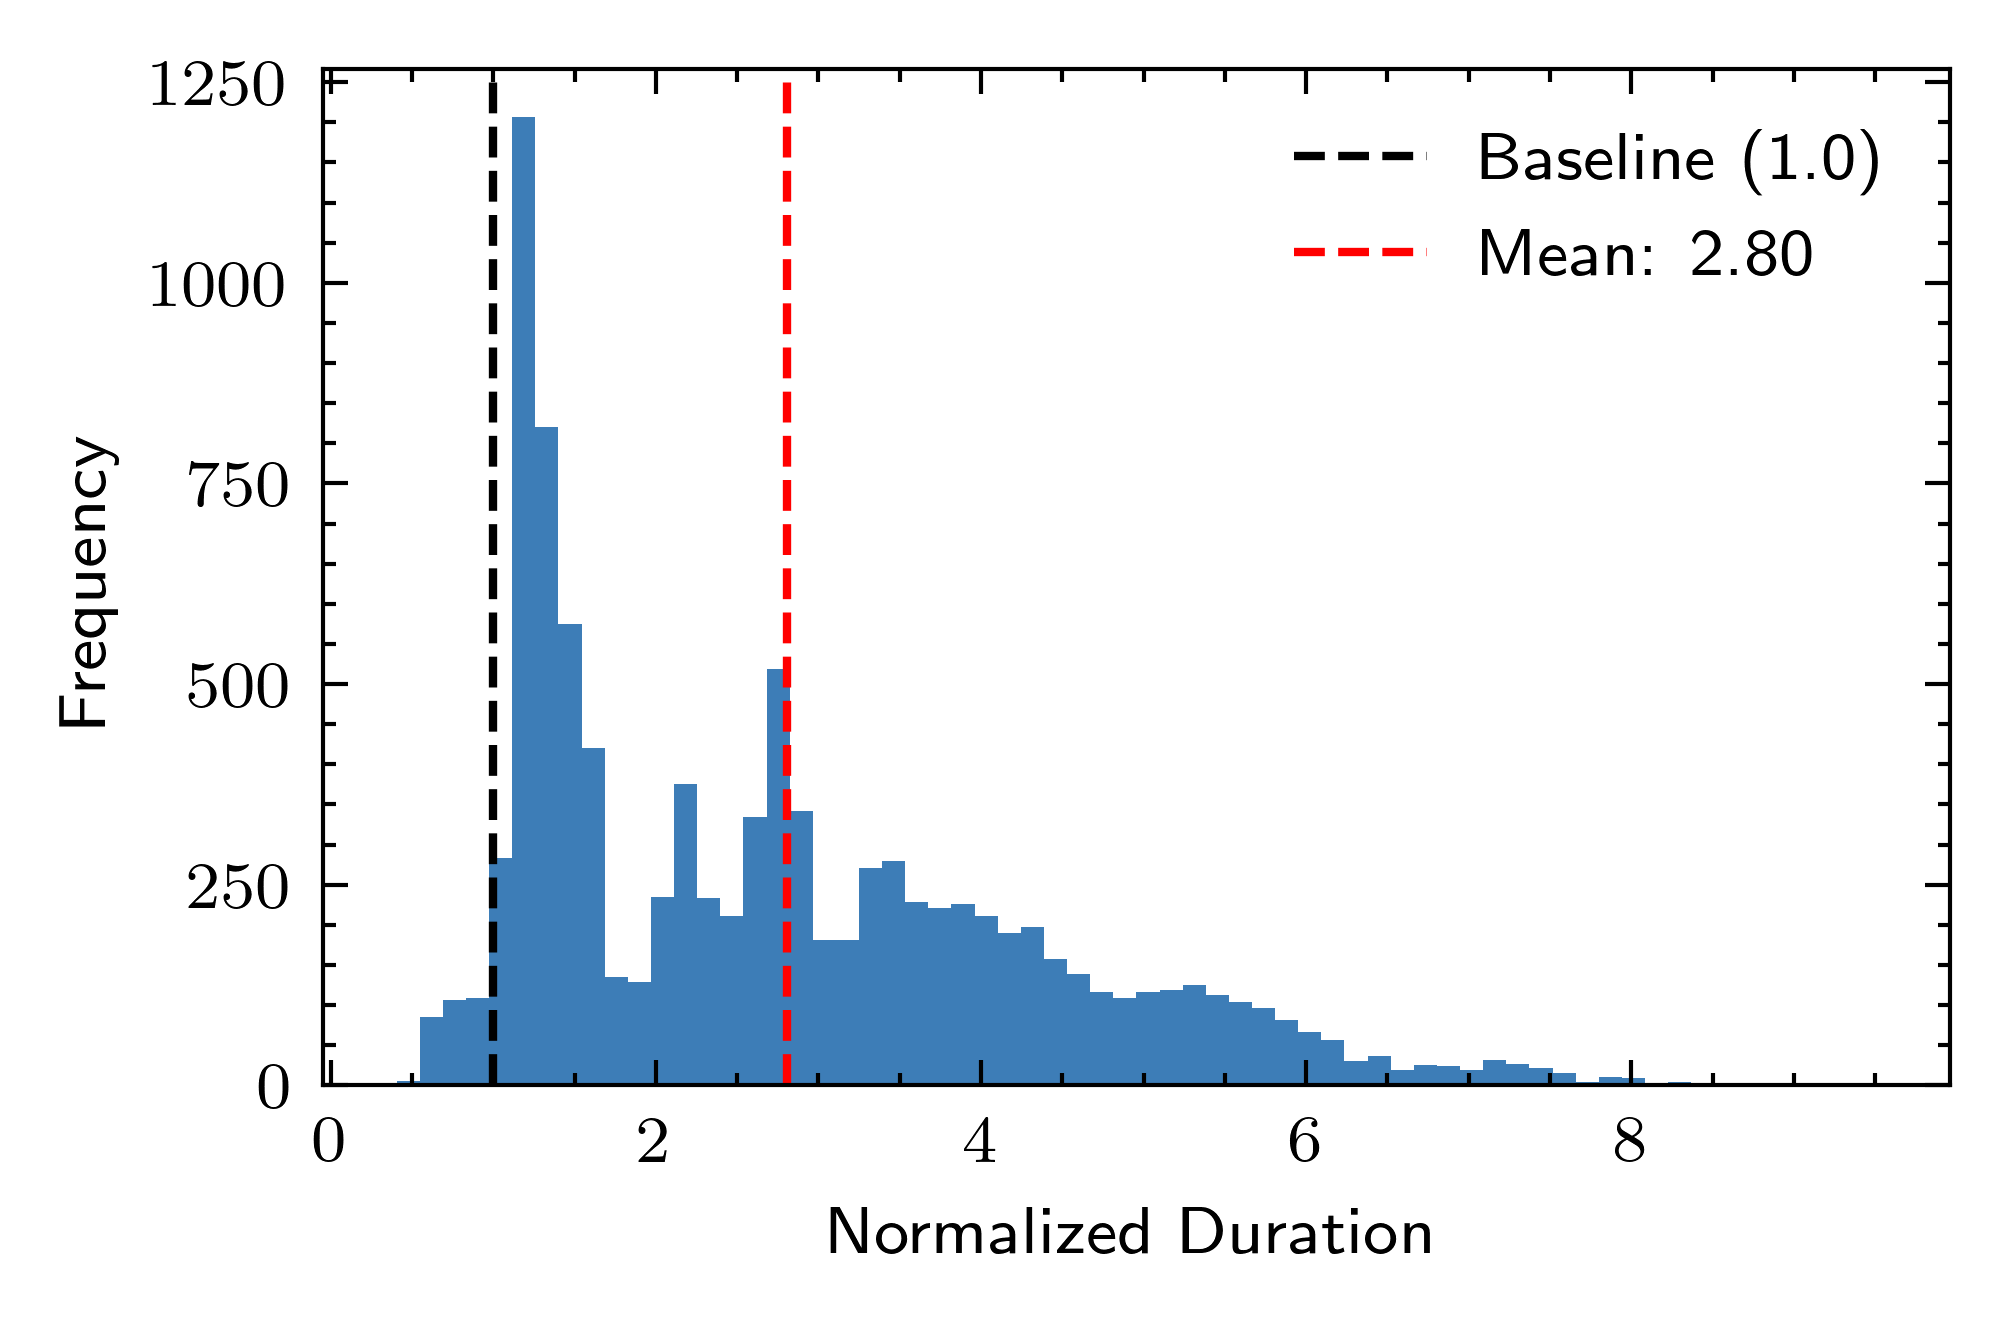

In [74]:
import matplotlib.pyplot as plt

# Calculate the speedup factor for each trial:
# Here, a ratio < 1 means monodromy-LP is faster, and >1 means slower.
speedup_ratios = np.array(mono_durations) / np.array(xx_durations)

with plt.style.context(["ieee", "use_mathtext", "science"]):
    fig, ax = plt.subplots(1, 1, figsize=(3.5, 2.2))

    bins = 64
    amax = 2.0  # Adjust based on expected speedup factor range

    ax.hist(speedup_ratios, bins=bins, alpha=0.8)

    # Plot a vertical line at 1, which is the baseline
    ax.axvline(1.0, color="black", linestyle="--", linewidth=1, label="Baseline (1.0)")

    mean_ratio = np.mean(speedup_ratios)
    std_ratio = np.std(speedup_ratios)
    ax.axvline(
        mean_ratio,
        color="red",
        linestyle="--",
        linewidth=1,
        label=f"Mean: {mean_ratio:.2f}",
    )

    ax.set_ylabel("Frequency")
    ax.set_xlabel("Normalized Duration")  # (monodromy-LP / XXDecomposer)")
    ax.legend()

plt.savefig(
    "monodromy_lp_vs_qiskit_XX_decomposer_speedup.pdf",
    bbox_inches="tight",
    dpi=300,
)
plt.show()

In [73]:
%reload_ext snakeviz
import cProfile

cProfile.run(
    "mono_lp_decomposer._best_decomposition(target)",
    "../../../docs/profile_timings/temp.prof",
)